<figure>
  <IMG SRC="https://ufaz-assets.ams3.digitaloceanspaces.com/ufaz_website_old/static/img/logo.png" WIDTH=150 ALIGN="right">
</figure>


# Project : Analysis of meteorological data
*Signal Processing in Geosciences / J. Vergne / Feb 2024*

---------

 Zahid Gadirov


-----

In this project long time series of meteorological data recorded at some places around the world areare analyzed.

The project applies Fourier Transform methods to identify dominant periodic components, designs digital filters to isolate low- and high-frequency signals, and evaluates correlations between datasets from different geographic locations.





In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import fft
from scipy import signal

%matplotlib inline

I chose data in Stockholm/Sweden and Berlin/Germany  between 2011-2018. While I was searching, I considered time step stability and existence of same data in 2 cities. I also considered "null" data abundance, it was too few.
Source: https://mesonet.agron.iastate.edu/request/download.phtml

In [ ]:
#Importing data
A = np.genfromtxt('ESKN.csv',delimiter=",",skip_header=1,usecols=(2,3,4,5),filling_values=(7.459,79.878,9.2,29.9))
temp=A[:,0] #temperature in C
hum=A[:,1] #relative humidity %
speed=A[:,2] #wind speed in mph
press=A[:,3] #air pressure

meantemp=np.mean(temp)
meanhum=np.mean(hum)
meanspeed=np.mean(speed)
meanpress=np.mean(press)
# for replacing "null" values, i found average values for each data.
#humidity graph


Representation of data in Time domain

Text(0, 0.5, 'Air pressure')

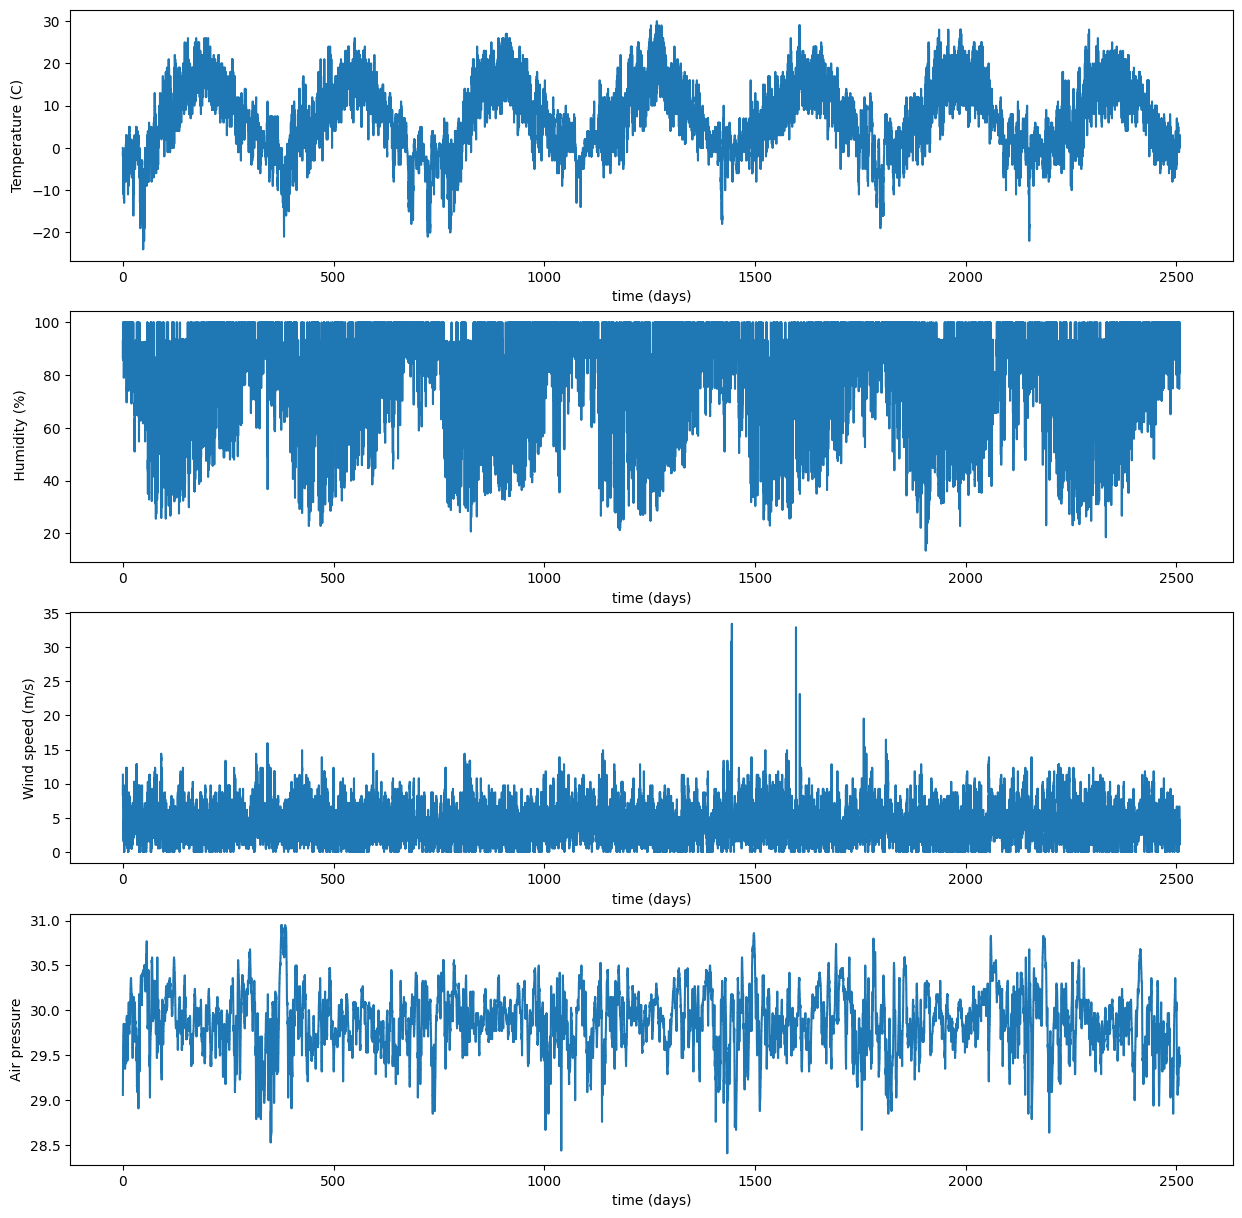

In [ ]:
dt=0.5/24  #time step in days
#temperature graph:

Ntemp=len(temp)
t=np.arange(0,Ntemp)*dt

plt.figure(figsize=(15,15))
h = plt.subplot(4,1,1)
plt.plot(t,temp)
plt.xlabel("time (days)")
plt.ylabel("Temperature (C)")


#humidity graph
Nhum=len(hum)
t=np.arange(0,Nhum)*dt
plt.subplot(4,1,2,sharex=h)
plt.plot(t,hum)
plt.xlabel("time (days)")
plt.ylabel(" Humidity (%)")

#wind speed graph:
Nspeed=len(speed)
t=np.arange(0,Nspeed)*dt
plt.subplot(4,1,3,sharex=h)

speed=speed/2.237 #conversion from mph to m/s

plt.plot(t,speed)
plt.xlabel("time (days)")
plt.ylabel("Wind speed (m/s)")
#altimeter graph:
Npress=len(press)
t=np.arange(0,Npress)*dt
plt.subplot(4,1,4,sharex=h)
plt.plot(t,press)
plt.xlabel("time (days)")
plt.ylabel("Air pressure")


>**Comments**  


-In temperature graph, we observe that it has peridocity 1 year, so in summer weather is warmer than in winter in Stockholm.

-In humidity graph, same periodicity(1year) exists, in winter the relative humidicitiy is higher than summer.

-For wind speed and air pressure varies during year.

Representation in Frequency domain


(0.0, 0.5)

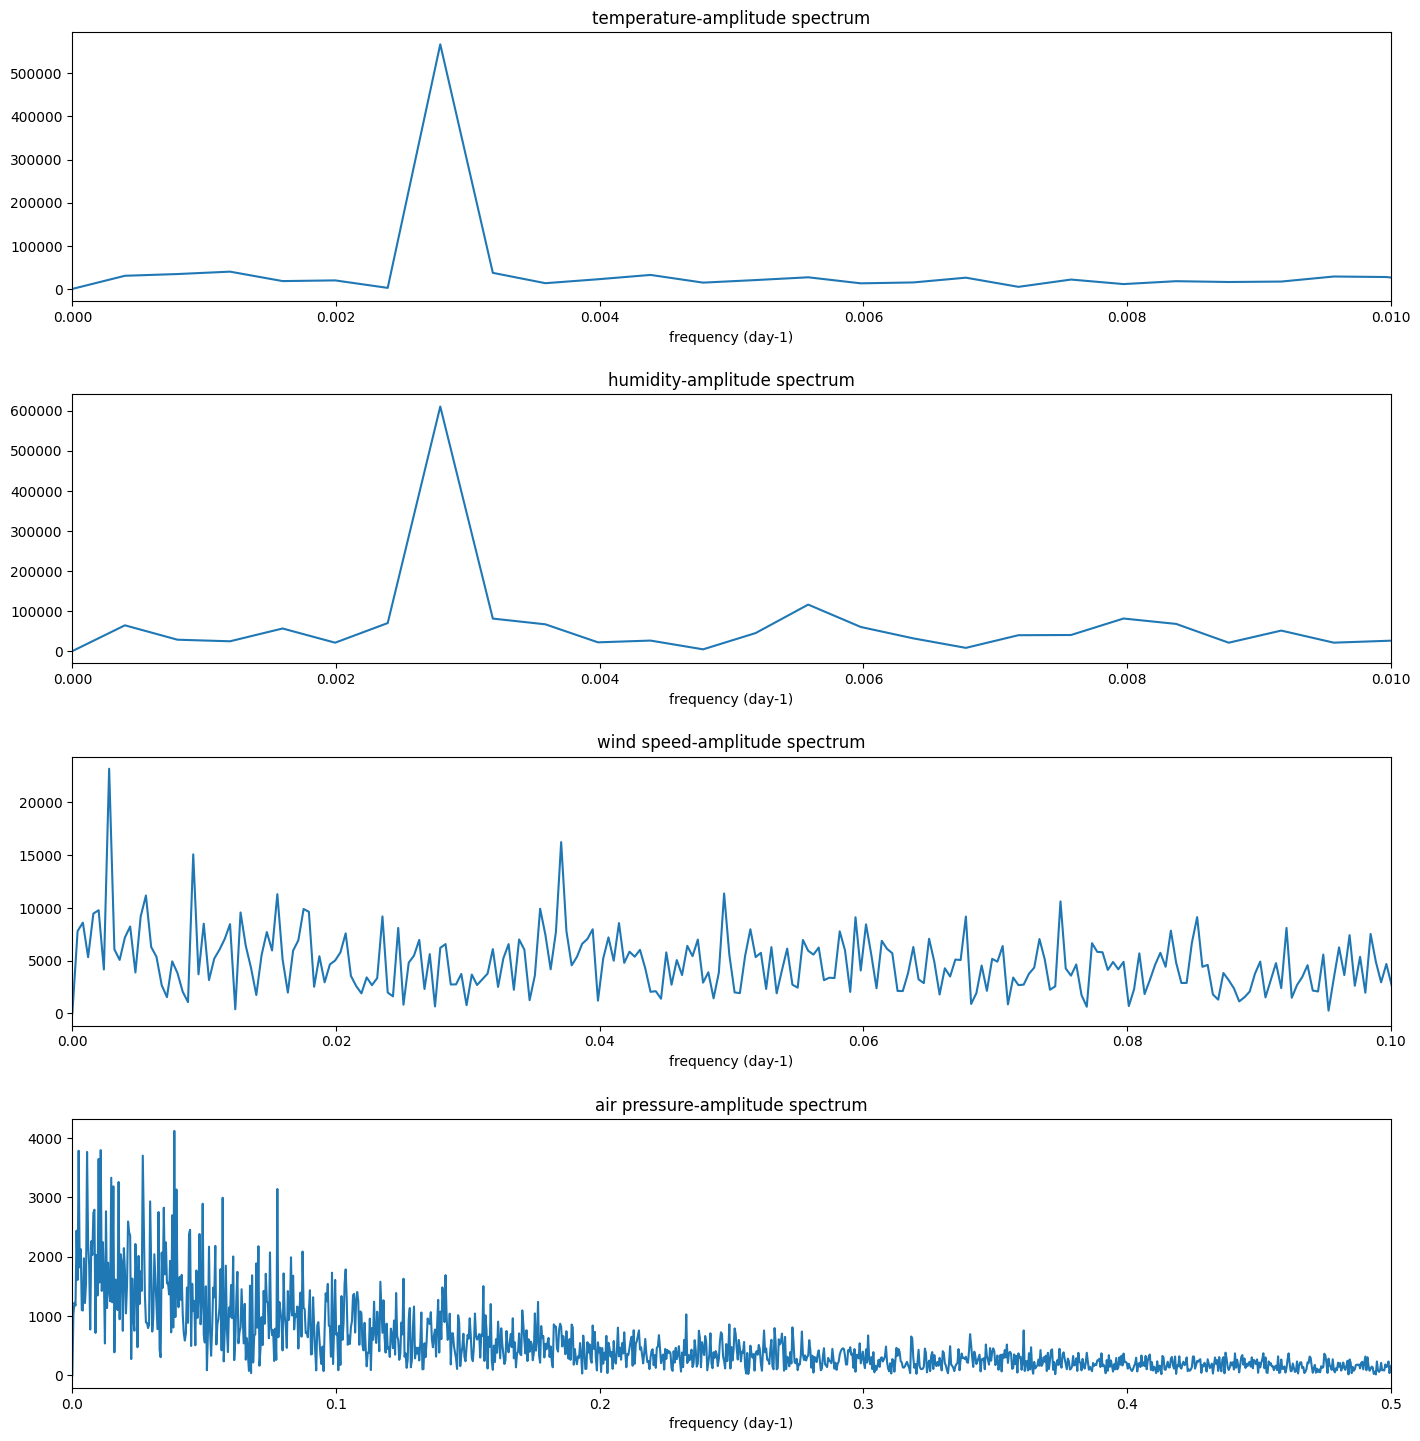

In [ ]:
#temperature
plt.figure(figsize=(15,15))
plt.subplot(4,1,1)
plt.tight_layout(pad=5.0)
temp=temp-np.mean(temp)
TEMP=fft.fft(temp)
f=fft.fftfreq(Ntemp,dt)
plt.plot(f[0:int(Ntemp/2)],np.abs(TEMP[0:int(Ntemp/2)]))
plt.xlabel('frequency (day-1)')
plt.title('temperature-amplitude spectrum')

plt.xlim(0,0.01)


#humidity
plt.subplot(4,1,2)
hum=hum-np.mean(hum)
HUM=fft.fft(hum)
f=fft.fftfreq(Nhum,dt)
plt.plot(f[0:int(Nhum/2)],np.abs(HUM[0:int(Nhum/2)]))
plt.xlabel('frequency (day-1)')
plt.title('humidity-amplitude spectrum')
plt.xlim(0,0.01)



#Wind speed
plt.subplot(4,1,3)
speed=speed-np.mean(speed)
SPEED=fft.fft(speed)
f=fft.fftfreq(Nspeed,dt)
plt.plot(f[0:int(Nspeed/2)],np.abs(SPEED[0:int(Nspeed/2)]))
plt.xlabel('frequency (day-1)')
plt.title('wind speed-amplitude spectrum')
plt.xlim(0,0.1)


#Air pressure
plt.subplot(4,1,4)
press=press-np.mean(press)
PRESS=fft.fft(press)
f=fft.fftfreq(Npress,dt)
plt.plot(f[0:int(Npress/2)],np.abs(PRESS[0:int(Npress/2)]))
plt.xlabel('frequency (day-1)')
plt.title('air pressure-amplitude spectrum')
plt.xlim(0,0.5)




>**Comments**  

-In first and second graphs, the 1 year periodicity is clear from frequency spectrum.

-For wind speed and air pressure, there is no clear periocity again, it varies.


------

 Filtering the data

b:  [4.27972054e-07 8.55944109e-07 4.27972054e-07]
a:  [ 1.         -1.9981488   0.99815051]


Text(0.5, 1.0, 'Air pressure low-pass filtered at 0.01 day-1')

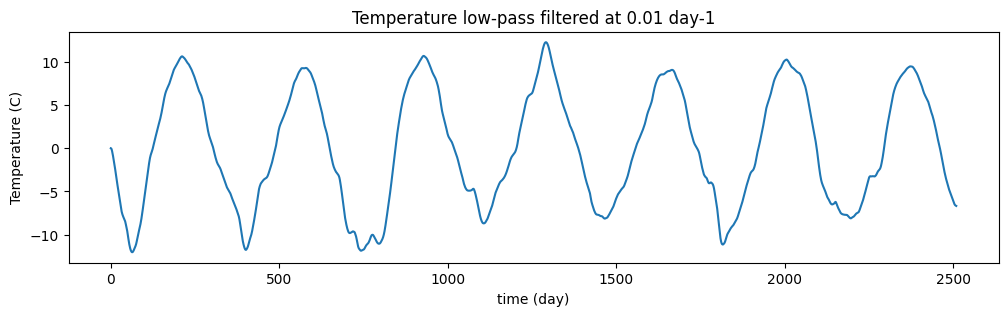

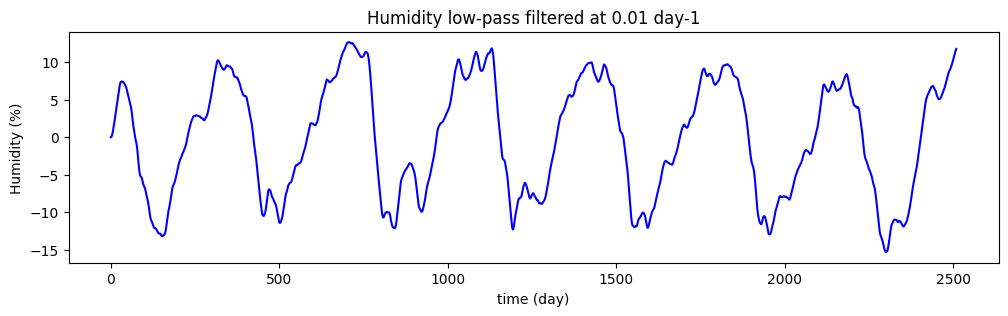

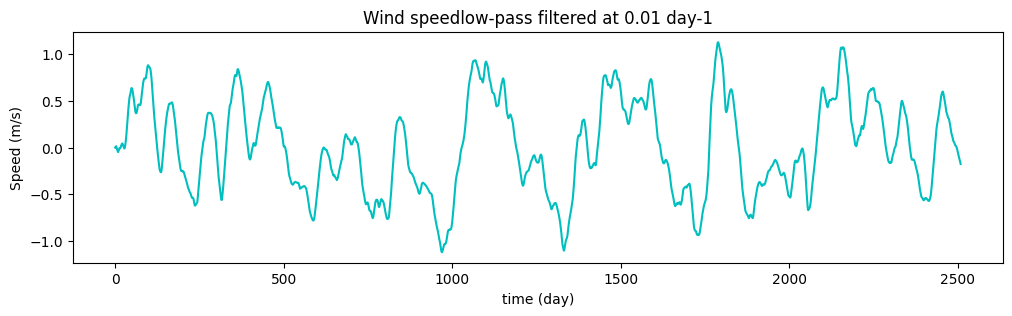

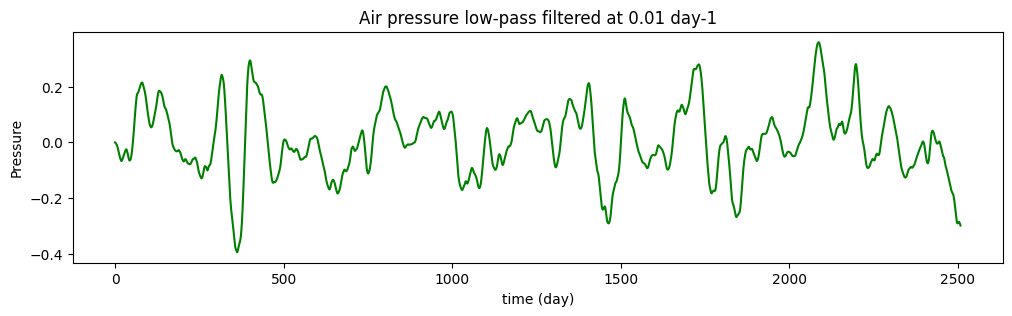

In [ ]:
#Low pass filtering
fcut = 0.01 #cutoff frequency in day-1
fs=1/dt
fcut_normalized = fcut / (fs/2)
b,a = signal.butter(2,fcut_normalized,btype='lowpass')
print('b: ', b)
print('a: ',a)


#temperature

tempfiltered = signal.lfilter(b,a,temp)
plt.figure(figsize=(12,3))
plt.plot(t,tempfiltered)
plt.xlabel('time (day)')
plt.ylabel('Temperature (C)')
plt.title('Temperature low-pass filtered at 0.01 day-1')

#Humidity

humfiltered = signal.lfilter(b,a,hum)
plt.figure(figsize=(12,3))
plt.plot(t,humfiltered,'b')
plt.xlabel('time (day)')
plt.ylabel('Humidity (%)')
plt.title('Humidity low-pass filtered at 0.01 day-1')

#Wind speed

speedfiltered = signal.lfilter(b,a,speed)
plt.figure(figsize=(12,3))
plt.plot(t,speedfiltered,'c')
plt.xlabel('time (day)')
plt.ylabel('Speed (m/s)')
plt.title('Wind speedlow-pass filtered at 0.01 day-1')

#Air pressure

pressfiltered = signal.lfilter(b,a,press)
plt.figure(figsize=(12,3))
plt.plot(t,pressfiltered,'g')
plt.xlabel('time (day)')
plt.ylabel('Pressure')
plt.title('Air pressure low-pass filtered at 0.01 day-1')

> **Comments**  

Here cutoff frequency is 0.01 day-1, filter may preserve faster changes than 0.01 day frequency and will block remaining ones. So, with using such kind of filters, we can reveal underlying trends more clearly.

Here, it is very easy to observe that temperature and humidity periodicity i 2 year.

And in Wind speed/Air pressure data, main periodicities are  more clear thanks to low pass filter.

------
3.2 High pass filter


Text(0.5, 1.0, ' Air pressire high-pass filtered at 0.01 day-1')

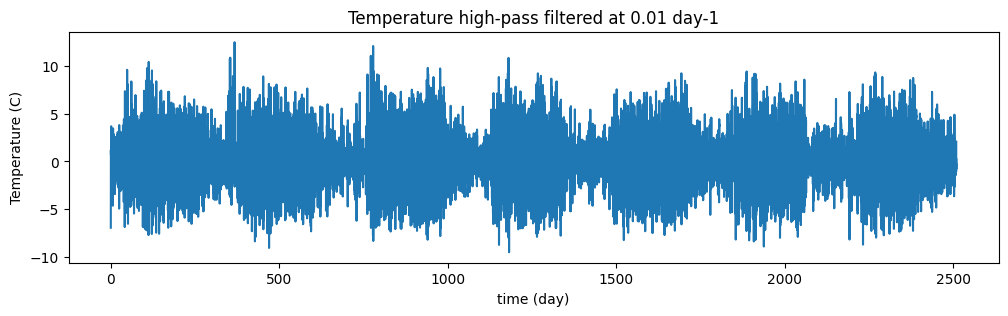

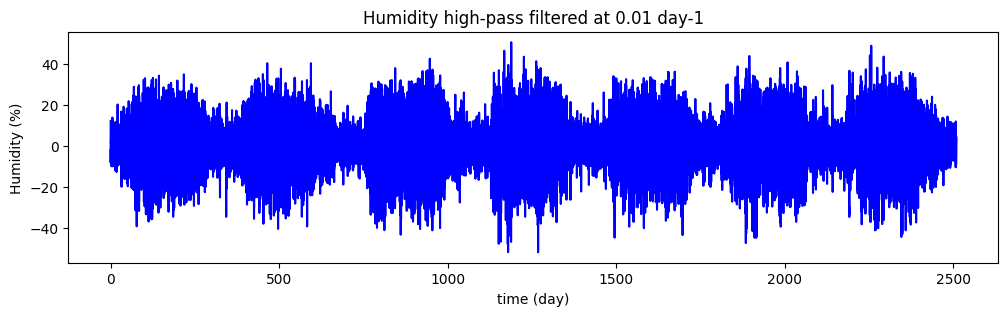

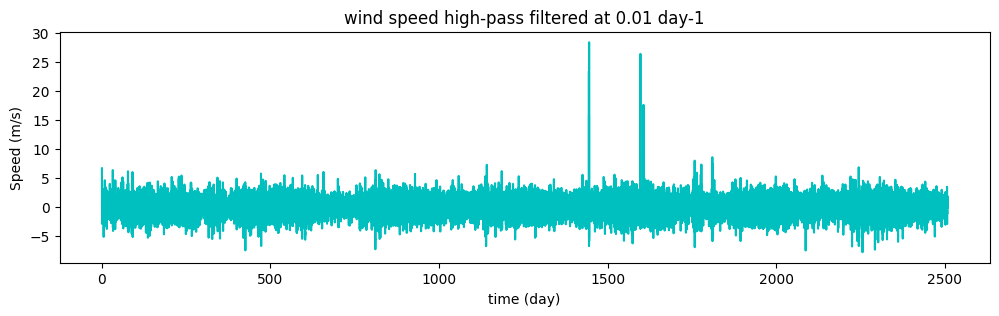

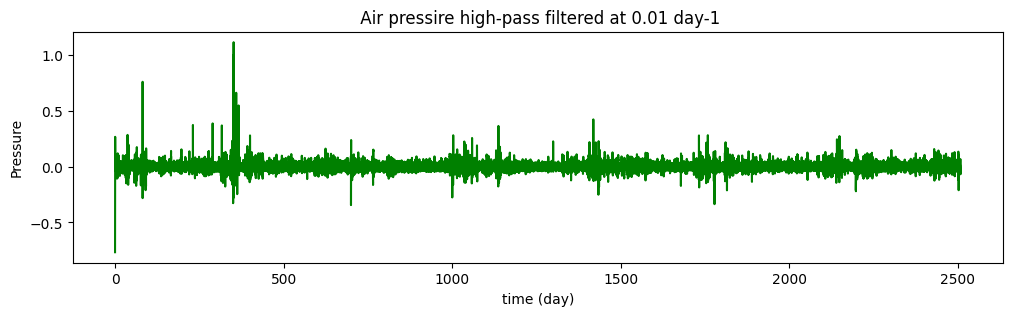

In [ ]:
fcut=0.8
fcut_normalized = fcut / (fs/2)
b, a = signal.butter(2,fcut_normalized,btype='highpass')


#temperature

tempfiltered = signal.lfilter(b,a,temp)
plt.figure(figsize=(12,3))
plt.plot(t,tempfiltered)
plt.xlabel('time (day)')
plt.ylabel('Temperature (C)')
plt.title('Temperature high-pass filtered at 0.01 day-1')

#Humidity

humfiltered = signal.lfilter(b,a,hum)
plt.figure(figsize=(12,3))
plt.plot(t,humfiltered,'b')
plt.xlabel('time (day)')
plt.ylabel('Humidity (%)')
plt.title('Humidity high-pass filtered at 0.01 day-1')

#Wind speed

speedfiltered = signal.lfilter(b,a,speed)
plt.figure(figsize=(12,3))
plt.plot(t,speedfiltered,'c')
plt.xlabel('time (day)')
plt.ylabel('Speed (m/s)')
plt.title('wind speed high-pass filtered at 0.01 day-1')

#Air pressure

pressfiltered = signal.lfilter(b,a,press)
plt.figure(figsize=(12,3))
plt.plot(t,pressfiltered,'g')
plt.xlabel('time (day)')
plt.ylabel('Pressure')
plt.title(' Air pressire high-pass filtered at 0.01 day-1')

> **Comments**  

As low pass filter, high pass filter also revealed some underlying information about these data, but in contrary high pass filter preserve higher frequencies than cutoff frequency=0.8 day-1.

In temperature/humidity data, periodicity is 1 year again.

In wind speed graph, there is a huge increase in one day, maybe because of some natural disaster.

------
Correlation between cities



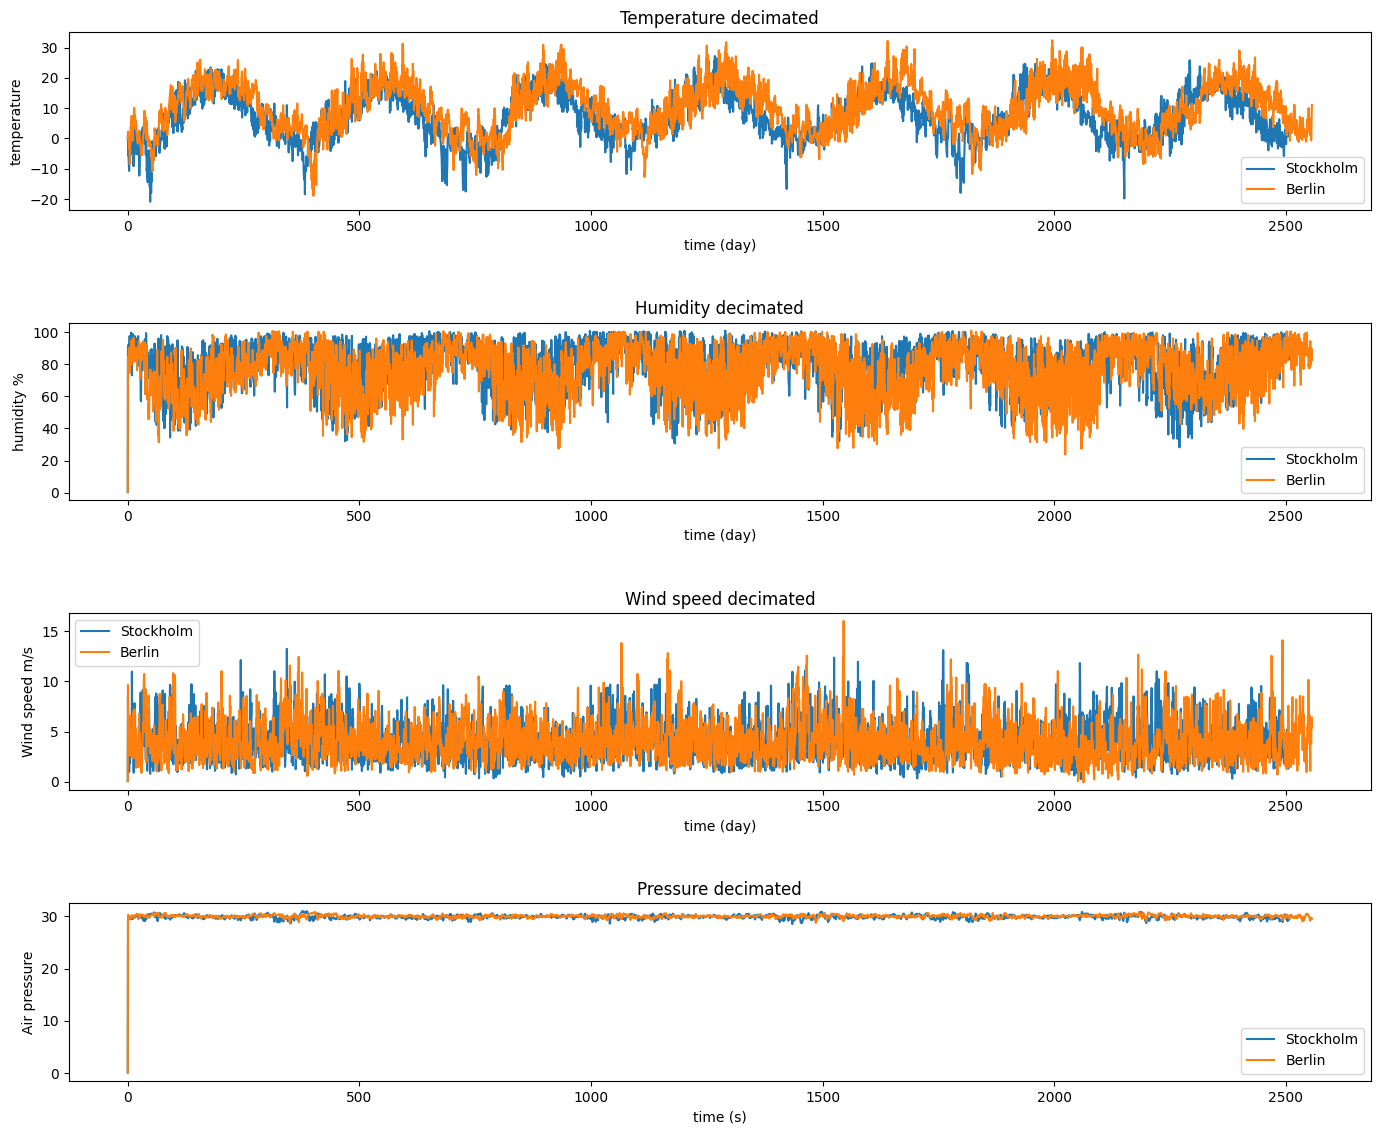

In [ ]:
cty1 = np.genfromtxt('ESKN.csv',delimiter=",",skip_header=1,usecols=(2,3,4,5),filling_values=(7.459,79.878,9.2,29.9))
temp1=cty1[:,0] #temperature in C
hum1=cty1[:,1] #relative humidity %
speed1=cty1[:,2] #wind speed in mph
press1=cty1[:,3] #air pressure

cty2 = np.genfromtxt('EDDB.csv',delimiter=",",skip_header=1,usecols=(2,3,4,5),filling_values=(10.24,76.34,9.13,29.99))
temp2=cty2[:,0] #temperature in C
hum2=cty2[:,1] #relative humidity %
speed2=cty2[:,2] #wind speed in mph
press2=cty2[:,3] #air pressure

dt=0.5/24

#                     Low pass filtering:

fcut = 1
fs=1/dt
fcut_normalized = fcut / (fs/2)
b,a = signal.butter(2,fcut_normalized,btype='lowpass')



#temperature

tempfiltered1 = signal.lfilter(b,a,temp1)
tempfiltered2 = signal.lfilter(b,a,temp2)

#Humidity

humfiltered1 = signal.lfilter(b,a,hum1)
humfiltered2 = signal.lfilter(b,a,hum2)


#Wind speed
speed1=speed1/2.237  #conversion to m/s
speed2=speed2/2.237

speedfiltered1 = signal.lfilter(b,a,speed1)
speedfiltered2 = signal.lfilter(b,a,speed2)



#Air pressure

pressfiltered1 = signal.lfilter(b,a,press1)
pressfiltered2 = signal.lfilter(b,a,press2)


#                        decimation:

df=24  #decimation factor

dtdec=df*dt
fsdec=1/dtdec

tempfiltered1dec=tempfiltered1[0::df]
tempfiltered2dec=tempfiltered2[0::df]



humfiltered1dec = humfiltered1[0::df]
humfiltered2dec = humfiltered2[0::df]

speedfiltered1dec = speedfiltered1[0::df]
speedfiltered2dec = speedfiltered2[0::df]

pressfiltered1dec = pressfiltered1[0::df]
pressfiltered2dec = pressfiltered2[0::df]


#                       Plotting the timeseries
t1=np.arange(0,len(temp1))*dtdec/24
t2=np.arange(0,len(temp2))*dtdec/24
t1dec=t1[0::df]
t2dec=t2[0::df]

#Temperature
plt.figure(figsize=(15,15))
plt.subplot(511)
plt.plot(t1dec,tempfiltered1dec)
plt.plot(t2dec,tempfiltered2dec)
plt.xlabel('time (day)')
plt.ylabel('temperature')
plt.title('Temperature decimated')
plt.legend(('Stockholm','Berlin'))

#Humidity
plt.tight_layout(pad=5.0)
plt.subplot(512)
plt.plot(t1dec,humfiltered1dec)
plt.plot(t2dec,humfiltered2dec)
plt.xlabel('time (day)')
plt.ylabel('humidity %')
plt.title('Humidity decimated')
plt.legend(('Stockholm','Berlin'))


#Wind speed
plt.subplot(513)
plt.plot(t1dec,speedfiltered1dec)
plt.plot(t2dec,speedfiltered2dec)
plt.xlabel('time (day)')
plt.ylabel('Wind speed m/s')
plt.title('Wind speed decimated')
plt.legend(('Stockholm','Berlin'))

#Pressure
plt.subplot(514)
plt.plot(t1dec,pressfiltered1dec)
plt.plot(t2dec,pressfiltered2dec)
plt.xlabel('time (s)')
plt.ylabel('Air pressure')
plt.title('Pressure decimated')
plt.legend(('Stockholm','Berlin'))


max correlation :  0.8827128028702889
optimal time shift (s) :  1.25
max correlation :  0.963190570103928
optimal time shift (s) :  0.5416666666666666
max correlation :  0.002666324648550398
optimal time shift (s) :  0.875
max correlation :  0.14021422271833248
optimal time shift (s) :  1.4375


Text(0.5, 0, 'time (s)')

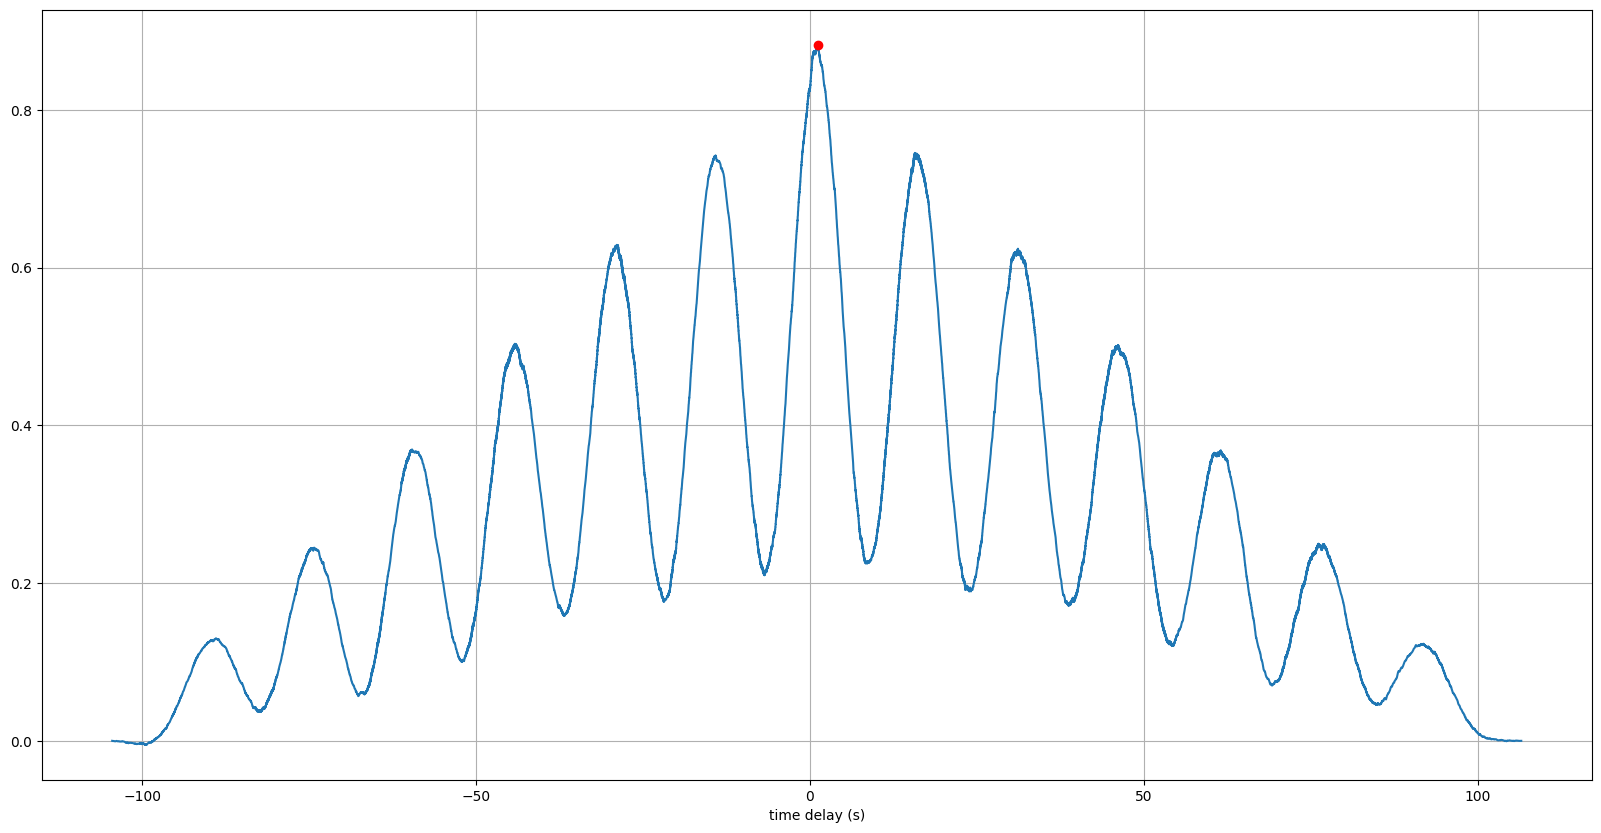

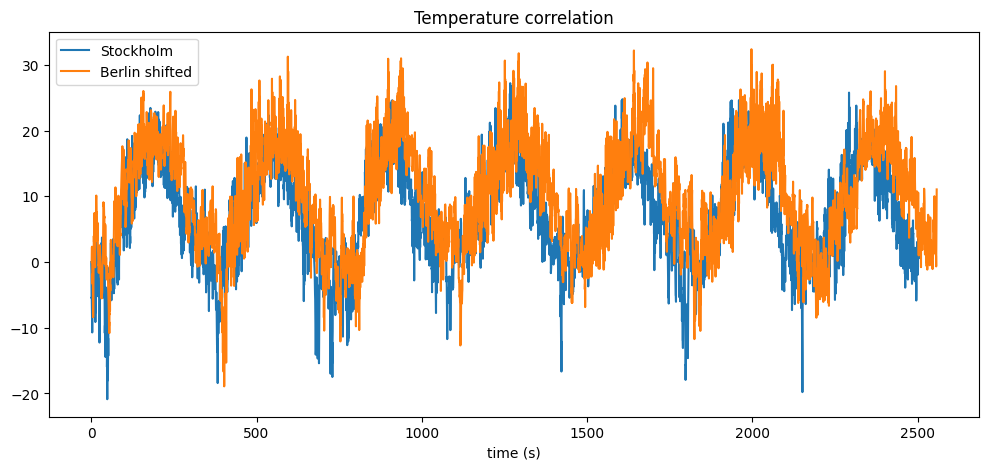

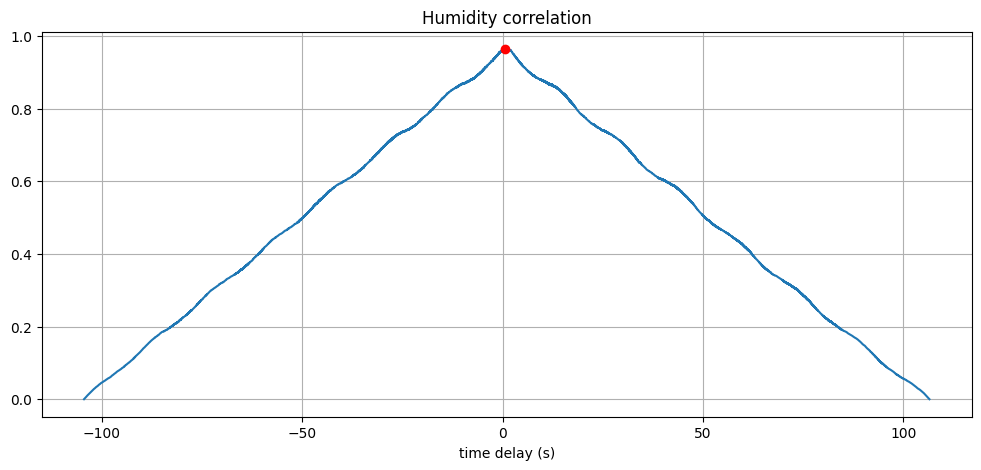

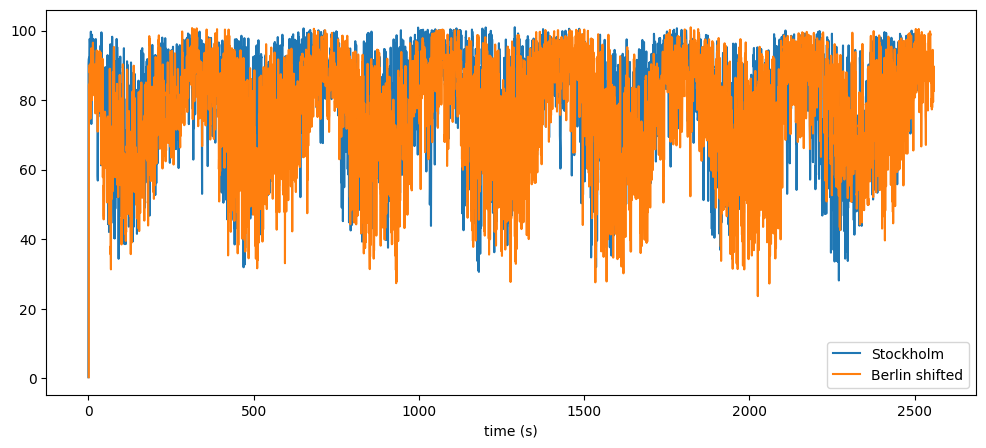

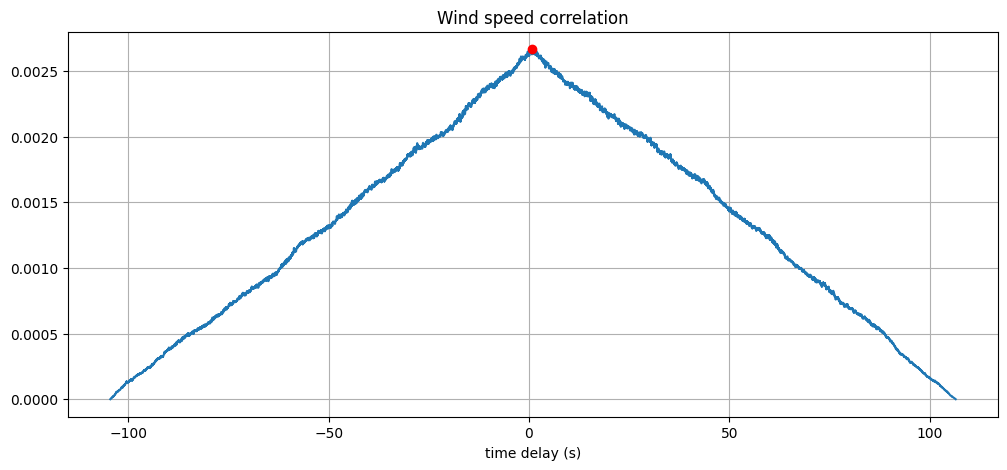

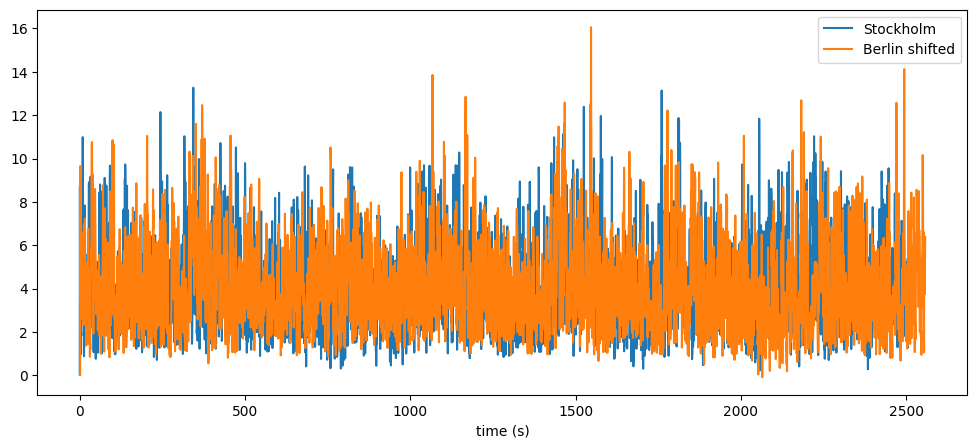

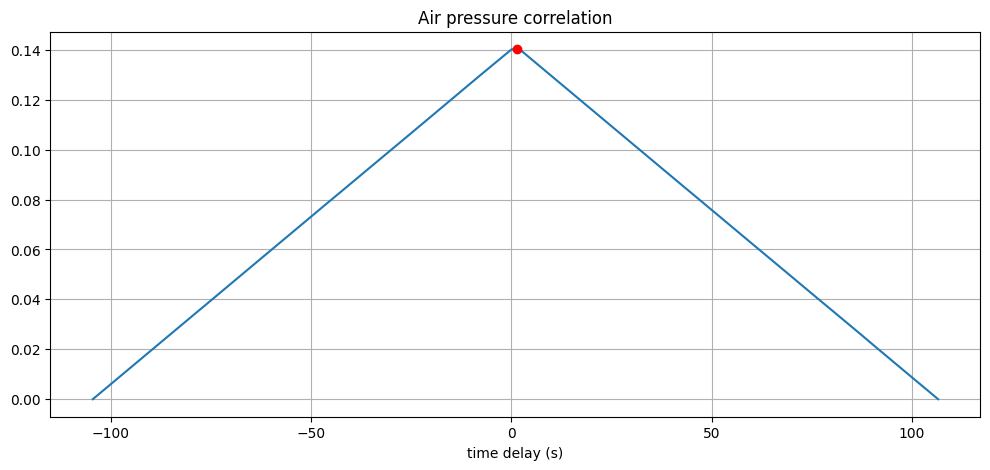

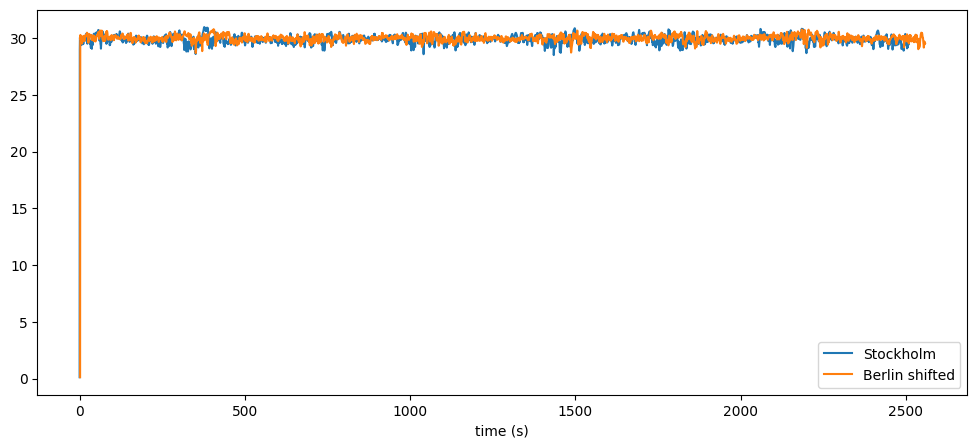

In [ ]:
#correlation

h1 = np.correlate(tempfiltered1dec,tempfiltered2dec,'full')
h2= np.correlate(humfiltered1dec,humfiltered2dec,'full')
h3 = np.correlate(speedfiltered1dec,speedfiltered2dec,'full')
h4 = np.correlate(pressfiltered1dec,pressfiltered2dec,'full')
t_corr = (np.arange(-len(speedfiltered1dec)+1,len(speedfiltered2dec)))*dt

# normalisation
norm_fact = np.sqrt(np.sum(tempfiltered1dec**2)*np.sum(tempfiltered2dec**2))
h1 = h1/norm_fact

# Plot correlation

#temperature
plt.figure(figsize=(20,10))
plt.plot(t_corr,h1)

plt.xlabel('time delay (s)')
plt.grid()

# maximum and shift
m1 = np.max(h1)
im1 = np.argmax(h1)
shift1 = t_corr[im1]
plt.plot(shift1,m1,'ro')
print('max correlation : ',m1)
print('optimal time shift (s) : ',shift1)

plt.figure(figsize=(12,5))
plt.plot(t1dec,tempfiltered1dec)
plt.plot(t2dec+shift1,tempfiltered2dec)
plt.legend(('Stockholm','Berlin shifted'))
plt.xlabel('time (s)')
plt.title('Temperature correlation')


#humidity

norm_fact = np.sqrt(np.sum(humfiltered1dec**2)*np.sum(humfiltered2dec**2))
h2 = h2/norm_fact
plt.figure(figsize=(12,5))
plt.plot(t_corr,h2)

plt.xlabel('time delay (s)')
plt.grid()
plt.title('Humidity correlation')



# maximum and shift

m2 = np.max(h2)
im2 = np.argmax(h2)
shift2 = t_corr[im2]
plt.plot(shift2,m2,'ro')
print('max correlation : ',m2)
print('optimal time shift (s) : ',shift2)

plt.figure(figsize=(12,5))
plt.plot(t1dec,humfiltered1dec)
plt.plot(t2dec+shift1,humfiltered2dec)
plt.legend(('Stockholm','Berlin shifted'))
plt.xlabel('time (s)')


#wind speed
norm_fact = np.sqrt(np.sum(humfiltered1dec**2)*np.sum(humfiltered2dec**2))
h3 = h3/norm_fact
plt.figure(figsize=(12,5))
plt.plot(t_corr,h3)

plt.xlabel('time delay (s)')
plt.grid()
plt.title('Wind speed correlation')

# maximum and shift
m3 = np.max(h3)
im3 = np.argmax(h3)
shift3 = t_corr[im3]
plt.plot(shift3,m3,'ro')
print('max correlation : ',m3)
print('optimal time shift (s) : ',shift3)

plt.figure(figsize=(12,5))
plt.plot(t1dec,speedfiltered1dec)
plt.plot(t2dec+shift1,speedfiltered2dec)
plt.legend(('Stockholm','Berlin shifted'))
plt.xlabel('time (s)')


#Air pressure
norm_fact = np.sqrt(np.sum(humfiltered1dec**2)*np.sum(humfiltered2dec**2))
h4 = h4/norm_fact
plt.figure(figsize=(12,5))
plt.plot(t_corr,h4)

plt.xlabel('time delay (s)')
plt.grid()
plt.title('Air pressure correlation')

# maximum and shift
m = np.max(h4)
im = np.argmax(h4)
shift = t_corr[im]
plt.plot(shift,m,'ro')
print('max correlation : ',m)
print('optimal time shift (s) : ',shift)

plt.figure(figsize=(12,5))
plt.plot(t1dec,pressfiltered1dec)
plt.plot(t2dec+shift,pressfiltered2dec)
plt.legend(('Stockholm','Berlin shifted'))
plt.xlabel('time (s)')



> **Comments**  

In temperature correlation graph, for Stockholm and Berlin, there is a strong correlation in temperature changes, this suggests similar climate conditions in these cities.

In humidity graph, as in temperature, there is strong correlation too, so similar weather patterns affects also relative humidity in these 2 cities.


This analysis demonstrates that:

The dominant spectral component corresponds to the annual climatic cycle.

Low-pass filtering effectively isolates seasonal variability.

High-frequency components reflect short-term meteorological fluctuations.

Correlation analysis indicates that large scale seasonal behavior is consistent between locations, while short-term variations remain locally influenced.